In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
population = pd.read_csv("us_pop_data.csv")

In [4]:
population.head()

,year,us_pop
0,1790,3929326
1,1800,5308483
2,1810,7239881
3,1820,9638453
4,1830,12866020


In [5]:
population["Years_Since_1790"] = population["year"] - 1790

population["Population_Millions"] = population["us_pop"] / 1000000

population.head()

,year,us_pop,Years_Since_1790,Population_Millions
0,1790,3929326,0,3.929326
1,1800,5308483,10,5.308483
2,1810,7239881,20,7.239881
3,1820,9638453,30,9.638453
4,1830,12866020,40,12.866020


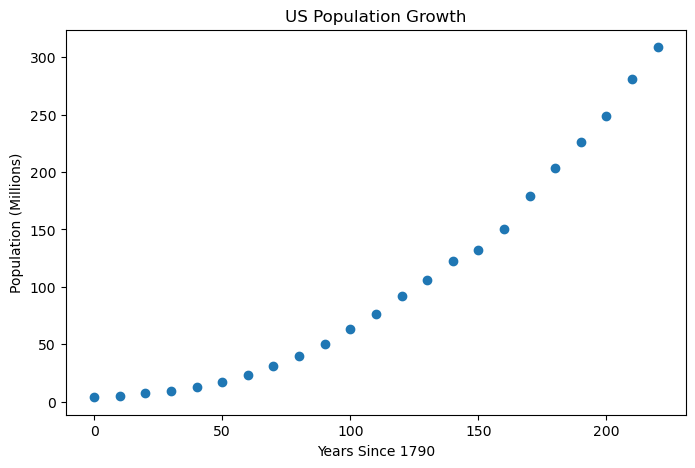

In [18]:
#create a scatter plot
plt.figure(figsize=(8,5))

plt.scatter(population["Years_Since_1790"],
            population["Population_Millions"])

plt.title("US Population Growth")
plt.xlabel("Years Since 1790")
plt.ylabel("Population (Millions)")

plt.show()

In [19]:
#create linear regression model 1
X = population[["Years_Since_1790"]]

y = population["Population_Millions"]

model1 = LinearRegression()

model1.fit(X, y)

predictions1 = model1.predict(X)

In [20]:
r2_model1 = r2_score(y, predictions1)

print("R² for Linear Model =", r2_model1)

R² for Linear Model = 0.9192437447080442


In [21]:
population["Years_Squared"] = population["Years_Since_1790"] ** 2

population.head()

,year,us_pop,Years_Since_1790,Population_Millions,Years_Squared
0,1790,3929326,0,3.929326,0
1,1800,5308483,10,5.308483,100
2,1810,7239881,20,7.239881,400
3,1820,9638453,30,9.638453,900
4,1830,12866020,40,12.866020,1600


In [22]:
#Build second regression model
X2 = population[["Years_Squared"]]

model2 = LinearRegression()

model2.fit(X2, y)

predictions2 = model2.predict(X2)

In [23]:
r2_model2 = r2_score(y, predictions2)

print("R² for Squared-Year Model =", r2_model2)

R² for Squared-Year Model = 0.9984915694986646


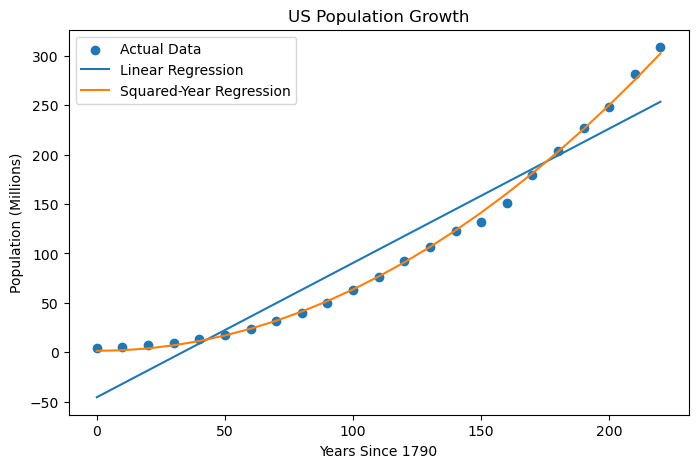

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(population["Years_Since_1790"],
            population["Population_Millions"],
            label="Actual Data")

plt.plot(population["Years_Since_1790"],
         predictions1,
         label="Linear Regression")

plt.plot(population["Years_Since_1790"],
         predictions2,
         label="Squared-Year Regression")

plt.title("US Population Growth")

plt.xlabel("Years Since 1790")

plt.ylabel("Population (Millions)")

plt.legend()

plt.show()

In [25]:
#F Discussion: While I believe the squared year regression model provides better variation over time because population growth is not perfectly linear over time, I prefer the linear regression model over it. I think it gives the overall growth at a glance without overwhelming the viewer. Depending on the detailed storyline we were to present, I could use either and either can be suitable. I find linear to be less overwhelming to eye, however if we were needing to exemplify the curve in population overtime than the former. 

In [26]:
#Load Data
customers = pd.read_csv("customer_spending.csv")

customers.head()

,ann_spending
0,34112
1,33266
2,36610
3,27381
4,46100


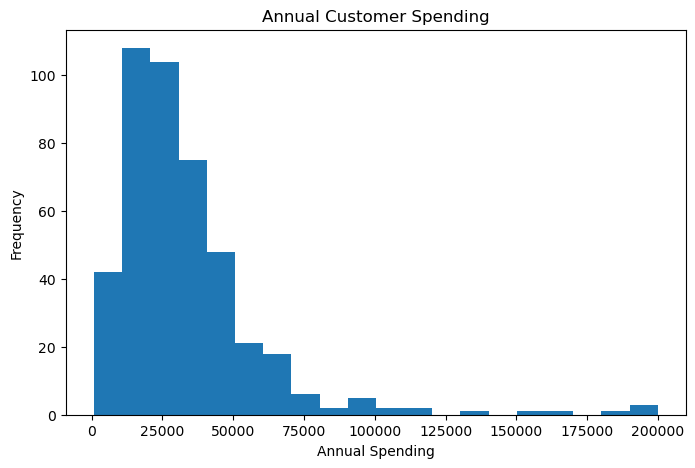

In [27]:
#Histogram of Customer Spending
plt.figure(figsize=(8,5))

plt.hist(customers["ann_spending"], bins=20)

plt.title("Annual Customer Spending")

plt.xlabel("Annual Spending")

plt.ylabel("Frequency")

plt.show()

In [28]:
#Create the log-transformed dataset
customers_log = customers.copy()

customers_log["ann_spending"] = np.log1p(customers_log["ann_spending"])

customers_log.head()

,ann_spending
0,10.437434
1,10.412321
2,10.508104
3,10.217641
4,10.738590


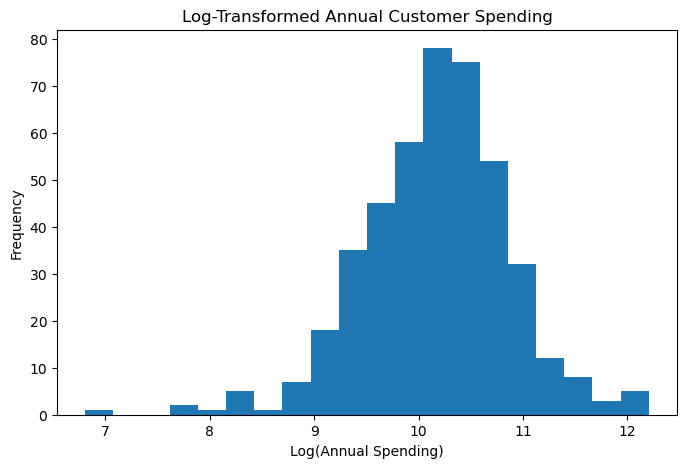

In [29]:
#Histogram of log-transformed data
plt.figure(figsize=(8,5))

plt.hist(customers_log["ann_spending"], bins=20)

plt.title("Log-Transformed Annual Customer Spending")

plt.xlabel("Log(Annual Spending)")

plt.ylabel("Frequency")

plt.show()

In [30]:
#d discussion: Comparing the two histograms to one another: the first is heavily right skewed because a small number of customers spend significantly more than the majority. After we did the log transformamtion, the distribution becomes more symmetrical and easier to intrepret. The log transformation makes data more suitable for statistical analysis and machine learning models by reducing the extreme values; being that data perfoms better when it has a normal distribution. 